<a href="https://colab.research.google.com/github/LOVELY1907/SAP_AI-ML-DL/blob/main/02_Machine_Learning/LogisticRegression1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler

In [ ]:
#Data Ingestion
df = pd.read_csv('/content/employee_appraisal_1000_rows.csv')

In [ ]:
df.sample(5)

,Employee_ID,Department,Education_Level,Job_Level,Performance_Rating,Years_Experience,Training_Hours,Monthly_Salary,Appraisal_Status
548,E0549,HR,Diploma,Mid,Low,1,76.0,30345,0
59,E0060,IT,PhD,Senior,Excellent,6,14.0,111057,1
707,E0708,Sales,Bachelor,Mid,Excellent,2,66.0,55464,0
605,E0606,Finance,Master,Senior,Good,9,31.0,86981,1
276,E0277,IT,Diploma,Lead,Low,12,33.0,86629,0


In [ ]:
#droping the Unintended Col
df.drop('Employee_ID',axis=1,inplace=True)

In [ ]:
df.isnull().sum()

,0
Department,0
Education_Level,0
Job_Level,0
Performance_Rating,0
Years_Experience,0
Training_Hours,10
Monthly_Salary,0
Appraisal_Status,0


<Axes: ylabel='count'>

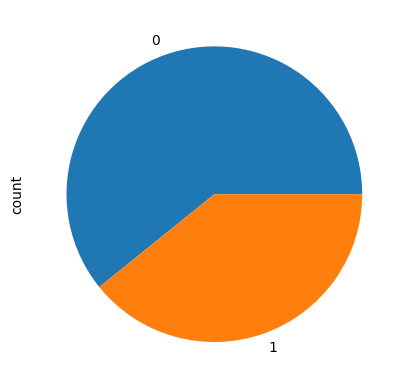

In [ ]:
df['Appraisal_Status'].value_counts().plot(kind= 'pie')

In [ ]:
df['Training_Hours'] = df['Training_Hours'].fillna(df['Training_Hours']).mean()

In [ ]:
df.select_dtypes(include='object').columns

Index(['Department', 'Education_Level', 'Job_Level', 'Performance_Rating'], dtype='object')

In [ ]:
df['Education_Level'].unique().tolist()

['Bachelor', 'Master', 'Diploma', 'PhD']

In [ ]:
df['Job_Level'].unique()

array(['Senior', 'Lead', 'Mid', 'Junior'], dtype=object)

In [ ]:
df['Performance_Rating'].unique()

array(['Excellent', 'Average', 'Low', 'Good'], dtype=object)

In [ ]:
ohe = OneHotEncoder(sparse_output=False)
education_cat = ['Diploma','Bachelor','Master','PhD']
job_cat = ['Junior','Mid','Senior','Lead']
per_cat = ['Low','Average','Good','Excellent']

lencoder = LabelEncoder()
odc = OrdinalEncoder(categories=[education_cat,job_cat,per_cat])

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
education_categories = ['Junior', 'Mid', 'Senior', 'Lead']
od = OrdinalEncoder(categories=[education_categories])
df['Job_Level']  = od.fit_transform(df[['Job_Level']])


In [ ]:
df.sample(5)

,Department,Education_Level,Job_Level,Performance_Rating,Years_Experience,Training_Hours,Monthly_Salary,Appraisal_Status
548,HR,Diploma,1.0,Low,1,54.921212,30345,0
576,IT,Master,0.0,Excellent,0,54.921212,51480,0
225,HR,Bachelor,0.0,Excellent,7,54.921212,30625,1
555,Sales,Diploma,1.0,Excellent,7,54.921212,65991,1
76,Sales,Bachelor,3.0,Average,3,54.921212,104607,0


In [ ]:
from sklearn.preprocessing import OrdinalEncoder
education_categories = ['High School', 'Diploma', 'Bachelor', 'Master', 'PhD']
od = OrdinalEncoder(categories=[education_categories])
df['Education_Level']  = od.fit_transform(df[['Education_Level']])
df['Education_Level']

,Education_Level
0,2.0
1,3.0
2,1.0
3,1.0
4,1.0
...,...
995,1.0
996,2.0
997,1.0
998,3.0


In [ ]:
from sklearn.preprocessing import LabelEncoder #output is lable of series
le = LabelEncoder()
df['Department'] = le.fit_transform(df['Department'])

In [ ]:
df.sample(5)

,Department,Education_Level,Job_Level,Performance_Rating,Years_Experience,Training_Hours,Monthly_Salary,Appraisal_Status
576,2,3.0,0.0,Excellent,0,54.921212,51480,0
621,1,2.0,2.0,Average,6,54.921212,111679,0
289,3,1.0,0.0,Excellent,1,54.921212,36103,0
411,3,2.0,2.0,Good,5,54.921212,94102,1
697,1,3.0,3.0,Low,12,54.921212,92307,0


In [ ]:
df.sample(5)

,Department,Education_Level,Job_Level,Performance_Rating,Years_Experience,Training_Hours,Monthly_Salary,Appraisal_Status
350,3,4.0,3.0,Excellent,7,54.921212,28210,1
769,2,1.0,0.0,Excellent,10,54.921212,98116,1
266,3,3.0,3.0,Excellent,0,54.921212,45939,0
281,3,3.0,2.0,Low,5,54.921212,91246,0
789,0,2.0,3.0,Low,0,54.921212,109959,0


In [ ]:
from sklearn.preprocessing import OrdinalEncoder
education_categories = ['Low', 'Average', 'Good','Excellent']
od = OrdinalEncoder(categories=[education_categories])
df['Performance_Rating']  = od.fit_transform(df[['Performance_Rating']])
df['Performance_Rating']

,Performance_Rating
0,3.0
1,1.0
2,1.0
3,3.0
4,0.0
...,...
995,3.0
996,3.0
997,1.0
998,1.0


In [ ]:
df.sample(5)

,Department,Education_Level,Job_Level,Performance_Rating,Years_Experience,Training_Hours,Monthly_Salary,Appraisal_Status
470,2,1.0,3.0,3.0,13,54.921212,98768,1
861,2,2.0,3.0,1.0,1,54.921212,85785,0
921,0,1.0,3.0,2.0,2,54.921212,114813,0
482,2,2.0,0.0,0.0,13,54.921212,112435,0
543,1,1.0,3.0,1.0,11,54.921212,105238,0


In [ ]:
X = df.drop('Appraisal_Status',axis=1)
Y = df['Appraisal_Status']

In [ ]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2, random_state=42)

In [ ]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [ ]:
lr = LogisticRegression()
lr.fit(X_train_scaled,Y_train)

LogisticRegression()

In [ ]:
Y_pred = lr.predict(X_test_scaled)

In [ ]:
Y_pred

array([0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1,
       0, 0])

In [ ]:
Y_pred.shape

(200,)

In [ ]:
X_test_scaled.shape

(200, 7)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test,Y_pred)

0.885

In [ ]:
from sklearn.metrics import r2_score
r2_score(Y_test,Y_pred)

0.5093333333333334

<Axes: >

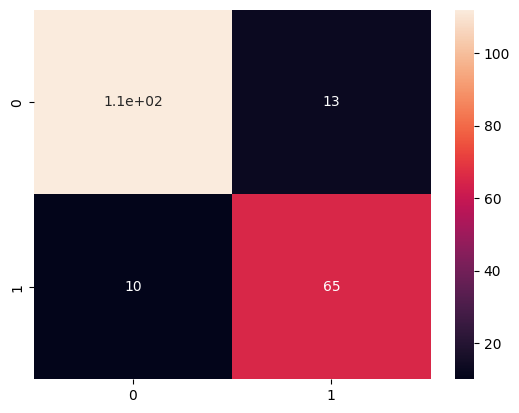

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_obj = confusion_matrix(Y_test,Y_pred)
sns.heatmap(confusion_obj, annot=True)